# Heatmaps of experimental data on network nodes

Bar charts (see the CKN tutorial) show one number per comparison. When the data has more
structure, e.g. treatments × time points, a small heatmap per node shows it better. This
tutorial makes such heatmaps with matplotlib, and shows them on the nodes in Cytoscape.

The data is the proteomics experiment of the CKN tutorial (case study 2 of the
[SKM publication](https://doi.org/10.1016/j.xplc.2024.100920)): logFC after 10 and 30
minutes of H₂O₂, with mock or LaCl₃ (Ca²⁺ channel inhibitor) pre-treatment. Each protein
gets a 2 × 2 heatmap, as in the publication:

|  | mock | LaCl₃ |
|---|---|---|
| **10 min** | logFC | logFC |
| **30 min** | logFC | logFC |

with significant changes (p < 0.05) marked by a star. The Cytoscape cells (the last section) need a running
Cytoscape; the heatmaps themselves are made without it.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import TwoSlopeNorm

from skm_tools.annotations import get_nodes_by_mapman
from skm_tools.ckn import ckn_to_networkx, filter_ckn_edges, filter_ckn_nodes
from skm_tools.paths import get_paths, path_subgraph

data_dir = Path("data")
output_dir = Path("output")
heatmap_dir = output_dir / "heatmaps"
for folder in (data_dir, output_dir, heatmap_dir):
    folder.mkdir(exist_ok=True)

proteomics_file = Path("../publication/case-study-2/data/merged-proteomics-data.tsv")

## The network

The paths from Ca²⁺-related genes to the proteins that changed most, as in the CKN
tutorial (see there for the details).

<div class="alert alert-info">

**A subset, to keep this tutorial fast:** the 10 responsive proteins with the largest
change after 10 minutes, instead of all of them.

</div>

In [2]:
ckn = ckn_to_networkx(data_dir / "ckn-edges.tsv.gz", data_dir / "ckn-nodes.tsv.gz")
filter_ckn_nodes(ckn, species=["ath"], tissues=["leaf", "not assigned"])
filter_ckn_edges(ckn, keep_edge_ranks=[0, 1, 2])

proteomics = pd.read_csv(proteomics_file, sep="\t", index_col=0)
responsive = [p for p in proteomics.index[proteomics["responsiveness"].notna()] if p in ckn]
targets = (proteomics.loc[responsive, "Mock|Mock vs Mock|H2O2 (10 min) log-FC"].abs()
           .sort_values(ascending=False).index[:10].tolist())

paths = get_paths(ckn, get_nodes_by_mapman(ckn, "27.8"), targets, shortest_overall=True)
net = path_subgraph(paths, ckn)
print(net)

Removed 1849 nodes from network.


Removed 724551 edges from network.


DiGraph with 89 nodes and 119 edges


## The data of a node, as a matrix

For each protein, the logFC and the p-values as 2 × 2 matrices: rows are the time
points, columns the pre-treatments.

In [3]:
TIMES = ["10 min", "30 min"]
TREATMENTS = {"mock": "Mock|Mock vs Mock|H2O2", "LaCl₃": "La3+|Mock vs La3+|H2O2"}


def matrices(protein):
    """(logFC, p-value) as 2 x 2 arrays: rows TIMES, columns TREATMENTS."""
    row = proteomics.loc[protein]
    logfc = np.array([[row[f"{t} ({time}) log-FC"] for t in TREATMENTS.values()] for time in TIMES],
                     dtype=float)
    pvalue = np.array([[row[f"{t} ({time}) p-value"] for t in TREATMENTS.values()] for time in TIMES],
                      dtype=float)
    return logfc, pvalue


matrices(targets[0])

(array([[ 3.21794, -0.39206],
        [ 0.5498 , -0.19762]]),
 array([[1.e-05,    nan],
        [   nan,    nan]]))

## Drawing a heatmap

As in the publication: a blue-white-red colour map from logFC -1 to 1 (the same scale for
all nodes; stronger changes get the end colours), missing values in grey, thick black
borders, and a white star on significant changes (p < 0.05). The images have no axes,
as they are shown next to the nodes; the legend is made separately.

In [4]:
CMAP = plt.get_cmap("bwr").with_extremes(bad="lightgrey")
NORM = TwoSlopeNorm(vmin=-1, vcenter=0, vmax=1)
P_CUTOFF = 0.05


def draw_heatmap(ax, protein, star_size=30, line_width=4):
    logfc, pvalue = matrices(protein)
    ax.pcolormesh(np.ma.masked_invalid(logfc), cmap=CMAP, norm=NORM, edgecolors="black",
                  linewidth=line_width)
    for row, col in zip(*np.nonzero(pvalue < P_CUTOFF)):
        # marker (6, 2, 0): a six-pointed star (asterisk)
        ax.plot(col + 0.5, row + 0.5, marker=(6, 2, 0), markersize=star_size,
                markeredgecolor="white", markeredgewidth=star_size / 6)
    ax.invert_yaxis()  # 10 min on top
    ax.set_aspect("equal")
    ax.axis("off")


def save_heatmap(protein, path):
    fig, ax = plt.subplots()
    draw_heatmap(ax, protein)
    fig.savefig(path, transparent=True, bbox_inches="tight", pad_inches=0)
    plt.close(fig)

The heatmaps of the targets, with their names, and the legend:

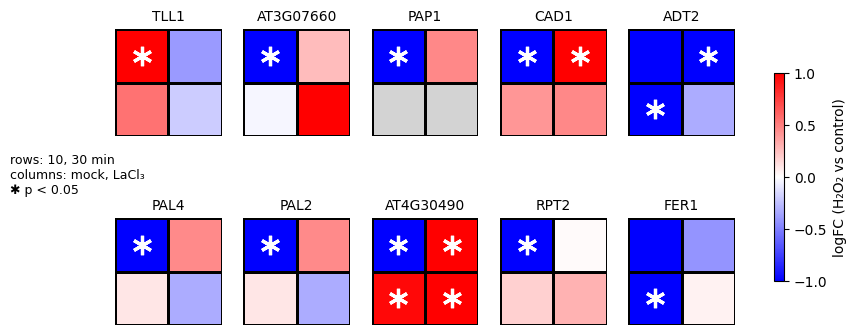

In [5]:
fig, axes = plt.subplots(2, 5, figsize=(10, 4.5))
label = dict(net.nodes(data="display_label"))
for ax, protein in zip(axes.flat, targets):
    draw_heatmap(ax, protein, star_size=14, line_width=2)
    ax.set_title(label[protein], fontsize=10)

colourbar = fig.colorbar(plt.cm.ScalarMappable(norm=NORM, cmap=CMAP), ax=axes, shrink=0.6,
                         label="logFC (H₂O₂ vs control)")
fig.text(0.02, 0.5, "rows: 10, 30 min\ncolumns: mock, LaCl₃\n✱ p < 0.05", va="center", fontsize=9)
plt.show()

## One image per node

The image files are named after the nodes, so that they can be matched to the nodes in
Cytoscape: `node_file_key` turns a node name into a file name (the gene ids here stay as
they are). Only the nodes with data get an image.

In [6]:
from skm_tools.cytoscape_utils import node_file_key

with_data = [n for n in net if n in proteomics.index]
for protein in with_data:
    save_heatmap(protein, heatmap_dir / f"{node_file_key(protein)}.png")
print(len(with_data), "heatmaps in", heatmap_dir)

31 heatmaps in output/heatmaps


## Cytoscape

The rest of this tutorial needs a running Cytoscape and the `cytoscape` extra
(`pip install "skm-tools[cytoscape]"`). We load the network with the SKM style, load the
image locations into a node table column, and show that column below the nodes in a copy
of the style.

Cytoscape caches images, and can show an old image after a file has changed. With
`unique_dir`, `load_node_images` first copies the images to new, unique file names, so
Cytoscape always loads them fresh.

In [7]:
# ci-skip: needs a running Cytoscape
import py4cytoscape as p4c
from IPython.display import Image

from skm_tools import cytoscape_utils as cu

p4c.cytoscape_ping()

'You are connected to Cytoscape!'

In [8]:
# ci-skip: needs a running Cytoscape
suid = cu.load_network(net, title="Ca2+ paths: heatmaps", collection="Tutorial: heatmaps", style="skm")
p4c.layout_network("force-directed", network=suid)

images = cu.match_files_to_nodes(heatmap_dir, net.nodes())
cu.load_node_images(images, "heatmap", network=suid, unique_dir=output_dir / "heatmaps-unique")

style = cu.copy_style("SKM", "SKM-heatmaps", networks=[suid])
cu.show_node_images(style, "heatmap", position="below", size=50)

Applied SKM to 37104


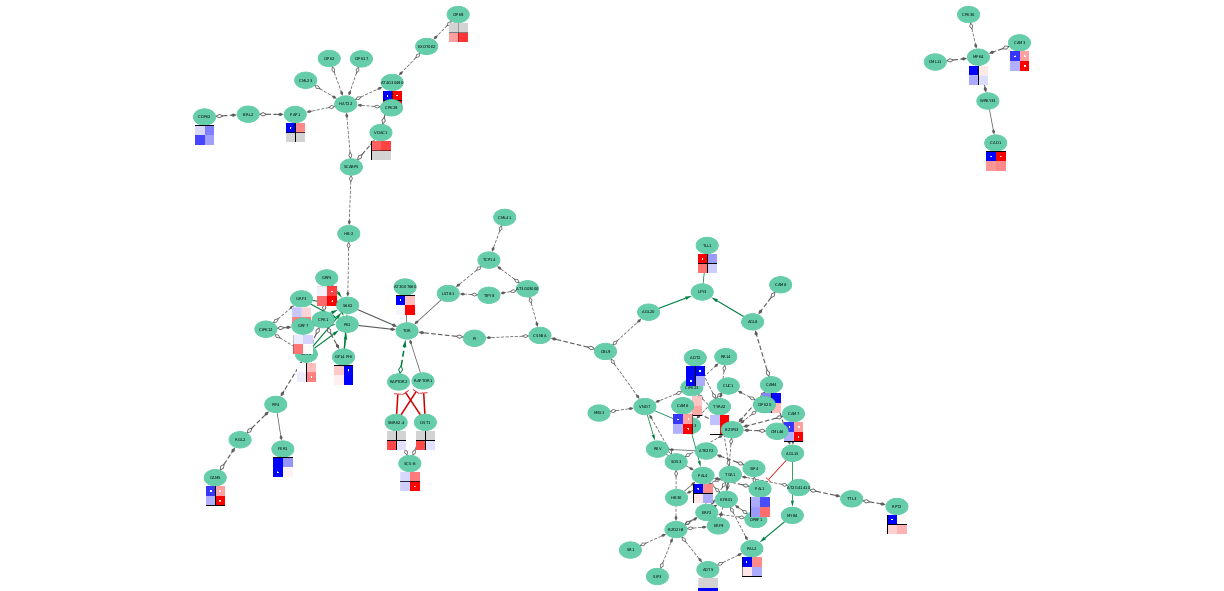

In [9]:
# ci-skip: needs a running Cytoscape
cu.export_network(suid, output_dir / "ckn-heatmaps.png", format="PNG", zoom=150)
Image(output_dir / "ckn-heatmaps.png")